# Leveraging Big Multitemporal Multisource Satellite Data and Artificial Intelligence for the Detection of Complex and Invisible Features - the Case of Extensive Irrigation Mapping


Nazarij Buławka 1*, Hector A. Orengo 2, 3, Felipe Lumbreras Ruiz 4 , Iban Berganzo-Besga 3 and Ekta Gupta 5

1.	Non-Invasive and Digital Archeology Laboratory (PANiC), Faculty of Archaeology, University of Warsaw
2.	Catalan Institution for Research and Advanced Studies (ICREA)
3.	Computational Social Sciences and Humanities Department, Barcelona Supercomputing Center
4.	Department of Computer Science, Universidad Autónoma de Barcelona,
5.	Landscape Archaeology Research Group (GIAP), Catalan Institute of Classical Archaeology


 ## Levee detection demo

The file contains the demonstration of the Swin UNETR model for the detection of the levees. The original model is run in the Docker environment, which is published in the GitHub repository.


The demo consist of six steps

1. Setup
2. Download the data and the model
3. Predict the levees
4. Apply post-processing
5. Evaluate the results
6. Visualise the results


# Citation

Buławka, Nazarij, Hector A. Orengo, Felipe Lumbreras Ruiz, Iban Berganzo-Besga and Ekta Gupta. n.d. ‘Leveraging Big Multitemporal Multisource Satellite Data and Artificial Intelligence for the Detection of Complex and Invisible Features - the Case of Extensive Irrigation Mapping’.


## 1. Setup

### Clone the repository

In [ ]:
!git clone https://github.com/nazarb/Levees_DL.git

fatal: destination path 'Levees_DL' already exists and is not an empty directory.


### Set up path for further processing

In [ ]:
import os
basepath = os.getcwd()
print(basepath)
# set other paths for quick navigation
git_path = os.path.join(basepath, "Levees_DL")
print(git_path)
Swin_UNETR_path = os.path.join(git_path, "Swin_UNETR")
print(Swin_UNETR_path)
model_path = os.path.join(Swin_UNETR_path, "model/Swin_UNETR/Aug")
results_path = os.path.join(Swin_UNETR_path, "results/Swin_UNETR/Aug")
rasters_path = os.path.join(git_path, "Rasters")
os.makedirs(results_path, exist_ok=True)
os.makedirs(rasters_path, exist_ok=True)
reference_path = f'{git_path}/Reference'
os.makedirs(reference_path, exist_ok=True)
print(results_path)


/content
/content/Levees_DL
/content/Levees_DL/Swin_UNETR
/content/Levees_DL/Swin_UNETR/results/Swin_UNETR/Aug


### Install libraries

In [ ]:
!pip install --no-cache-dir monai==1.3.2


In [ ]:
!pip install rasterio


In [ ]:

import warnings
warnings.filterwarnings("ignore")
import torch
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.cuda.is_available()
torch.cuda.device_count()
torch.cuda.current_device()
torch.cuda.get_device_name(0)

'Tesla T4'

## 2. Download the data and the model

The raster data used in this study is calculated with the provided Google Earth Engine code. The model is published in the Dane Badawcze UW repository (Published version: 2025-09-24):

```
Buławka, Nazarij; Orengo, Hector A.; Lumbreras Ruiz, Felipe; Berganzo-Besga, Iban; Gupta, Ekta, 2025, "Traces of ancient irrigation in central Iraq detected using deep learning model", https://doi.org/10.58132/MY8CCL, Dane Badawcze UW, V1
```


In [ ]:
# Download the model and related files from the Dane Badawcze UW and RADOGOST repositories
#
# The deep learning model
# Buławka, Nazarij; Orengo, Hector A.; Lumbreras Ruiz, Felipe; # Berganzo-Besga, Iban; Gupta, Ekta, 2025,
# "Traces of ancient irrigation in central Iraq detected using deep learning model"
# https://doi.org/10.58132/MY8CCL
# Dane Badawcze UW, V1
#
# Raster used for prediction
# Buławka, Nazarij; Orengo, Hector A.; Lumbreras Ruiz, Felipe; Berganzo-Besga, Iban; Gupta, Ekta, 2026,
# "The multisource rasters for the detection of ancient irrigation traces - central Iraq - 48 bands",
# https://doi.org/10.82343/GNAVO3,
# RADOGOST, V1

import os
import shutil
import requests
from tqdm import tqdm

def download_file(url, output_path, chunk_size=8192):
    os.makedirs(os.path.dirname(output_path), exist_ok=True)

    print(f"Downloading from {url} ...")

    response = requests.get(url, stream=True)
    response.raise_for_status()

    total_size = int(response.headers.get("content-length", 0))

    with open(output_path, "wb") as file, tqdm(
        desc=os.path.basename(output_path),
        total=total_size,
        unit="B",
        unit_scale=True,
        unit_divisor=1024,
    ) as progress_bar:

        for chunk in response.iter_content(chunk_size=chunk_size):
            if chunk:
                file.write(chunk)
                progress_bar.update(len(chunk))

    print(f"Saved to {output_path}\n")

# -----------------------------
# 1. Input raster
# -----------------------------
raster_url = "https://radogost.dariah.pl/api/access/datafile/800"
raster_output = f"{rasters_path}/CFE_c_mlraster_L5_S2_S1_GLO_N48.tif"

download_file(raster_url, raster_output)
print("Input raster downloaded successfully.")

# -----------------------------
# 2. Trained model (.pth)
# -----------------------------
model_url = "https://danebadawcze.uw.edu.pl/api/access/datafile/17759"
model_output = f"{model_path}/Levees_SWINUNETR_48_best_dataset_F.pth"

download_file(model_url, model_output)
print("The Swin Unetr deep learning model downloaded successfully")
print("All downloads completed successfully.")

CFE_c_mlraster_L5_S2_S1_GLO_N48.tif: 100%|██████████| 1.01G/1.01G [00:50<00:00, 21.6MB/s]


Saved to /content/Levees_DL/Rasters/CFE_c_mlraster_L5_S2_S1_GLO_N48.tif

Input raster downloaded successfully.


Levees_SWINUNETR_48_best_dataset_F.pth: 100%|██████████| 134M/134M [00:07<00:00, 18.8MB/s]

Saved to /content/Levees_DL/Swin_UNETR/model/Swin_UNETR/Aug/Levees_SWINUNETR_48_best_dataset_F.pth

The Swin Unetr deep learning model downloaded successfully
All downloads completed successfully.


## 3. Predict the levees
Area: southeast of Babylon


In [ ]:
# Check the paths for further processing

Swin_UNETR_pth = model_output # downloaded model
print({Swin_UNETR_pth})

data_path =  raster_output  # downloaded raster for prediction
print(data_path)


{'/content/Levees_DL/Swin_UNETR/model/Swin_UNETR/Aug/Levees_SWINUNETR_48_best_dataset_F.pth'}
/content/Levees_DL/Rasters/CFE_c_mlraster_L5_S2_S1_GLO_N48.tif


In [ ]:
#import monai
#from monai.inferers import sliding_window_inference
from monai.networks.nets import SwinUNETR
#import einops
#import warnings
#import json
#import numpy as np
import torch
#from torch.utils.data import Dataset, DataLoader
import os
#
#from rasterio.windows import Window
#import tifffile as tiff
from Levees_DL.utils import get_filename_without_extension
from Levees_DL.utils import predict_and_save
from Levees_DL.utils import convert_tiles_to_npy
from Levees_DL.utils import save_full_raster
from Levees_DL.utils.datasets import NumpyDataset
from Levees_DL.utils import load_large_image
from Levees_DL.utils import prepare_test_loader, split_to_tiles, create_tfw_file


filename_to_detect = get_filename_without_extension(data_path)


def initialize_model():
    """Initialize the SwinUNETR model."""
    model = SwinUNETR(
        img_size=(96, 96),
        in_channels=48,
        out_channels=1,  # Use the passed `num_classes`
        use_checkpoint=True,
        feature_size=48,
        depths=(3, 9, 18, 3),
        num_heads=(4, 8, 16, 32),
        drop_rate=0.1,  # Added dropout
        attn_drop_rate=0.1,
        dropout_path_rate=0.2,
        spatial_dims=2
    )
    return model


def load_adapted_model(model, checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location='cpu')
    model.load_state_dict(checkpoint, strict=False)
    return model




if __name__ == "__main__":
    image_path = data_path

    tile_size = 96
    batch_size = 12
    model = initialize_model()

    print("Loading and preprocessing the large image")
    large_image, transform = load_large_image(image_path)
    large_image = NumpyDataset.replace_nans_in_array(large_image)
    image_shape = large_image.shape
    print(f"Large image shape: {image_shape}")

    temp_dir = f'{Swin_UNETR_path}/results/temp/'
    npy_dir = f'{Swin_UNETR_path}/results/temp_npy/'
    pred_dir = f'{Swin_UNETR_path}/results/temp_pred/'
    result_path = f'{Swin_UNETR_path}/results/Swin_UNETR/Aug/{filename_to_detect}_swinunetr.tif'
    tfw_path = f'{Swin_UNETR_path}/results/Swin_UNETR/Aug/{filename_to_detect}_swinunetr.tfw'

    if not os.path.exists(temp_dir):
        os.makedirs(temp_dir)

    tile_paths = split_to_tiles(large_image, tile_size, temp_dir)
    npy_paths = convert_tiles_to_npy(tile_paths, npy_dir)
    test_loader = prepare_test_loader(npy_paths, batch_size)

    adapted_model_path = Swin_UNETR_pth
    model = load_adapted_model(model, adapted_model_path)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    predictions = predict_and_save(model, test_loader, device, tile_paths, save_dir=pred_dir)

    # Adjust the image_shape to reflect the single-channel output
    single_channel_image_shape = (1, image_shape[1], image_shape[2])
    save_full_raster(predictions, single_channel_image_shape, tile_size, result_path)

    # Create the .tfw file using the transform from the original large image
    create_tfw_file(transform, tfw_path)

    print("Prediction, saving, and .tfw file creation complete")



Loading and preprocessing the large image
Loading large image from /content/Levees_DL/Rasters/CFE_c_mlraster_L5_S2_S1_GLO_N48.tif
Large image shape: (48, 2994, 1746)
Splitting image into tiles of size 96x96
Saving tile to /content/Levees_DL/Swin_UNETR/results/temp/tile_0_0.tif
Saving tile to /content/Levees_DL/Swin_UNETR/results/temp/tile_0_96.tif
Saving tile to /content/Levees_DL/Swin_UNETR/results/temp/tile_0_192.tif
Saving tile to /content/Levees_DL/Swin_UNETR/results/temp/tile_0_288.tif
Saving tile to /content/Levees_DL/Swin_UNETR/results/temp/tile_0_384.tif
Saving tile to /content/Levees_DL/Swin_UNETR/results/temp/tile_0_480.tif
Saving tile to /content/Levees_DL/Swin_UNETR/results/temp/tile_0_576.tif
Saving tile to /content/Levees_DL/Swin_UNETR/results/temp/tile_0_672.tif
Saving tile to /content/Levees_DL/Swin_UNETR/results/temp/tile_0_768.tif
Saving tile to /content/Levees_DL/Swin_UNETR/results/temp/tile_0_864.tif
Saving tile to /content/Levees_DL/Swin_UNETR/results/temp/tile_0_9

## 4. Apply post-processing

In [ ]:
import numpy as np
import cv2
import os
from skimage import io
from Levees_DL.utils import create_tfw_file
from Levees_DL.utils import load_large_binary_image

## Load image for post-processing. You can use result_path from the previous step or use input
# # raster_r = input("Enter path to raster data: ").strip('"') # input

raster_r = result_path # the result_path from the previous step
filename_to_detect = get_filename_without_extension(raster_r) # get the thename for further processing
binary_raster, transform = load_large_binary_image(raster_r) # load image for prediction
binary_raster = (binary_raster > 0).astype(np.uint8)  # Ensure binary

# REMOVE SMALL OBJECTS
min_area = 350
#num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary_raster, connectivity=8)
num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary_raster, connectivity=8)

# Keep only features above the selected min_area parameter
filtered_raster = np.zeros_like(binary_raster, dtype=np.uint8)
for i in range(1, num_labels):  # skip background
    if stats[i, cv2.CC_STAT_AREA] >= min_area:
        filtered_raster[labels == i] = 1


# Output
output_dir = results_path
os.makedirs(output_dir, exist_ok=True)
filtered_dir = os.path.join(output_dir, "Filtered")
os.makedirs(filtered_dir, exist_ok=True)

# Save
filtered_tif_path = os.path.join(filtered_dir, f'{filename_to_detect}_filtered.tif')
io.imsave(filtered_tif_path, (filtered_raster * 1).astype(np.uint8))
create_tfw_file(transform, os.path.splitext(filtered_tif_path)[0] + '.tfw')

print("Filtering complete. Small features removed and .tfw file saved.")

# CLOSING
kernel = np.ones((7,7),np.uint8)
closing_raster = cv2.morphologyEx(filtered_raster, cv2.MORPH_CLOSE, kernel)

# SAVE CLOSING results
closing_tif_path = os.path.join(filtered_dir, f'{filename_to_detect}_closing.tif')
cv2.imwrite(closing_tif_path, (closing_raster * 1).astype(np.uint8))
create_tfw_file(transform, os.path.splitext(closing_tif_path)[0] + '.tfw')



Loading large image from /content/Levees_DL/Swin_UNETR/results/Swin_UNETR/Aug/CFE_c_mlraster_L5_S2_S1_GLO_N48_swinunetr.tif
Creating .tfw file at /content/Levees_DL/Swin_UNETR/results/Swin_UNETR/Aug/Filtered/CFE_c_mlraster_L5_S2_S1_GLO_N48_swinunetr_filtered.tfw
Filtering complete. Small features removed and .tfw file saved.
Creating .tfw file at /content/Levees_DL/Swin_UNETR/results/Swin_UNETR/Aug/Filtered/CFE_c_mlraster_L5_S2_S1_GLO_N48_swinunetr_closing.tfw


## 5. Evaluate the results


### Download the reference data


In [ ]:
# Download the reference data
# Buławka, Nazarij; Orengo, Hector A.; Lumbreras Ruiz, Felipe; Berganzo-Besga, Iban; Gupta, Ekta, 2026,
# "The multisource rasters for the detection of ancient irrigation traces - central Iraq - 48 bands",
# https://doi.org/10.82343/GNAVO3,
# RADOGOST, V1

# 1. Reference raster
# -----------------------------
reference_url = "https://radogost.dariah.pl/api/access/datafile/814"
reference_output = f"{reference_path}/CFE_c_levee_reference.tif"

download_file(reference_url, reference_output)


Reference_data_path = reference_output


CFE_c_levee_reference.tif: 100%|██████████| 19.9M/19.9M [00:01<00:00, 10.5MB/s]

Saved to /content/Levees_DL/Reference/CFE_c_levee_reference.tif



### Compare the predicted levees and the reference data - raster version

In [ ]:
import os
from Levees_DL.utils import read_tfw_coordinates
from Levees_DL.utils import align_reference_with_crs
from rasterio.crs import CRS
from Levees_DL.utils import compare_rasters
from rasterio.crs import CRS


reference_tif = Reference_data_path

#reference_tif = input("Enter path to reference data: ").strip('"') # If manual selection is needed
predicted_tif = closing_tif_path
#predicted_tif = input("Enter path to predicted data: ").strip('"') # If manual selection is needed


# Step 1: Read transform from TFW file
predicted_transform = read_tfw_coordinates(predicted_tif)

# Step 1b: Define CRS manually (replace EPSG code as needed!)
dst_crs = CRS.from_epsg(4326)   #

# Step 2: Align reference raster
aligned_ref_path = os.path.splitext(predicted_tif)[0] + "_ref_aligned.tif"
aligned_ref = align_reference_with_crs(reference_tif, predicted_tif, predicted_transform, dst_crs, aligned_ref_path)


metrics = compare_rasters(
    reference_tif=aligned_ref,
    predicted_tif=predicted_tif,
    IoU_buf=4,
    output_path="custom_comparison.tif"
)

print(f"Precision: {metrics['precision']:.4f}")
print(f"Recall: {metrics['recall']:.4f}")
print(f"F1 Score: {metrics['f1_score']:.4f}")
print(f"IoU: {metrics['iou']:.4f}")



[TFW] Affine transform read from file:

--- Evaluation Metrics ---
Precision:  0.6249
Recall:     0.5426
F1 Score:   0.5809
IoU:        0.4093
Comparison raster saved to:
custom_comparison.tif
Precision: 0.6249
Recall: 0.5426
F1 Score: 0.5809
IoU: 0.4093


The evaluation of the last version of the model after post-processing (min_area=350, IoU_buf=4) using Copernicus DEM GLO 30

| Dataset* | Model      | Test area | Prediction         | Precision | Recall | F1 Score | IoU    |
|----------|------------|-----------|--------------------|-----------|--------|----------|--------|
| F        | Swin UNETR | 1a        | Filtered + Closing | 0.6160    | 0.5504 | 0.5813   | 0.4098 |
| F        | Swin UNETR | 1b        | Filtered + Closing | 0.6291    | 0.5547 | 0.5896   | 0.4180 |
| F        | Swin UNETR | 1c        | Filtered + Closing | 0.6249    | 0.5426 | 0.5809   | 0.4093 |
| F        | Swin UNETR | 1d        | Filtered + Closing | 0.5877    | 0.5627 | 0.5749   | 0.4035 |
| F        | Swin UNETR | 1e        | Filtered + Closing | 0.5853    | 0.5102 | 0.5452   | 0.3747 |
| F        | Swin UNETR | 1f        | Filtered + Closing | 0.6042    | 0.5406 | 0.5706   | 0.3992 |
| F        | Swin UNETR | Average   | Filtered + Closing | 0.6079    | 0.5435 | 0.5738   | 0.4024 |


### Reproject the results


In [ ]:
from Levees_DL.utils import reproject_raster

reprojected_ouput_file = f'{filtered_dir}/{filename_to_detect}_swinunetr_closing_3857.tfw'

# Using TFW file for transform information
output = reproject_raster(
    closing_tif_path,
    reprojected_ouput_file,
    src_crs="EPSG:4326",
    dst_crs="EPSG:3857",
    use_tfw=True
)


[TFW] Affine transform read from file:
Reprojected raster saved to: /content/Levees_DL/Swin_UNETR/results/Swin_UNETR/Aug/Filtered/CFE_c_mlraster_L5_S2_S1_GLO_N48_swinunetr_swinunetr_closing_3857.tfw


#### Skeletonise

In [ ]:
# # Code created by Orengo, Hector A. (2026) 2026. Horengo/RasterToNetwork. Jupyter Notebook. January 21, released January 24. https://github.com/horengo/RasterToNetwork.

from Levees_DL.utils import skeletonize_raster

in_raster = reprojected_ouput_file
out_raster = os.path.join(filtered_dir, f'{filename_to_detect}_skeleton.tif')
skeldir = out_raster

binarize = lambda arr: (arr > 0)

out_raster = skeletonize_raster(
    in_raster=in_raster,
    out_raster=out_raster,
    binarize=binarize  # Optional: defaults to lambda arr: (arr > 0)
)

print(f"Done. Wrote skeleton raster: {out_raster}")

Done. Wrote skeleton raster: /content/Levees_DL/Swin_UNETR/results/Swin_UNETR/Aug/Filtered/CFE_c_mlraster_L5_S2_S1_GLO_N48_swinunetr_skeleton.tif


### Remove short lines

In [ ]:
# # Code created by Orengo, Hector A. (2026) 2026. Horengo/RasterToNetwork. Jupyter Notebook. January 21, released January 24. https://github.com/horengo/RasterToNetwork.

# Connected-pixel filtering of a binary channel raster (remove small components)
# - Reads a binary raster (0/1 or 0/255 etc.)
# - Labels connected components
# - Removes components with fewer than `min_pixels` pixels
# - Writes a filtered binary raster with the same georeferencing

from Levees_DL.utils import filter_connected_components

in_raster = skeldir
min_pixels = 50          # remove components smaller than this (in pixels)
connectivity = 8         # 4 or 8 (8 is usually better for channel networks)
out_raster = os.path.join(filtered_dir, f'{filename_to_detect}_skeleton_{min_pixels}_{connectivity}.tif')
skeldir_sm = out_raster

# If your raster is not strictly 0/1, define how to binarize it:
# e.g., channels are values > 0
binarize = lambda arr: (arr > 0)

# ---------------------

# Use utils function to filter connected components
out_raster = filter_connected_components(
    in_raster=in_raster,
    out_raster=out_raster,
    min_pixels=min_pixels,
    connectivity=connectivity,
    binarize=binarize  # Optional: defaults to lambda arr: (arr > 0)
)

print(f"Done. Wrote: {out_raster}")
print(f"Removed components with < {min_pixels} pixels (connectivity={connectivity}).")

Done. Wrote: /content/Levees_DL/Swin_UNETR/results/Swin_UNETR/Aug/Filtered/CFE_c_mlraster_L5_S2_S1_GLO_N48_swinunetr_skeleton_50_8.tif
Removed components with < 50 pixels (connectivity=8).


In [ ]:
!pip install sknw
!pip install geopandas shapely

### Convert to vector

In [ ]:
# # Code created by Orengo, Hector A. (2026) 2026. Horengo/RasterToNetwork. Jupyter Notebook. January 21, released January 24. https://github.com/horengo/RasterToNetwork.

# Cell: Transform a filtered skeleton raster (0/1) into a network with:
#  - endpoint↔endpoint gap bridging (angle + distance)
#  - endpoint→vertex snapping (attach dangling endpoints to nearby line vertices)
#  - degree-2 contraction (analysis network)
#  - optional parallel/near-parallel connector creation (with proper node insertion)
#  - optional directionality from a slope-direction/aspect raster
# 1. Install dependencies (if not already done)
# !pip install sknw geopandas shapely  # Already done

# 2. Reload the module
import importlib
import sys

# Clear the cached module
if 'Levees_DL.utils.raster_to_network' in sys.modules:
    del sys.modules['Levees_DL.utils.raster_to_network']

# Re-import
from Levees_DL.utils.raster_to_network import raster_to_network as build_network

# 3. Verify sknw is available
import sknw
print("✓ sknw is available")

# ---- USER PARAMS ------------------------------------------------------------
in_skeleton = skeldir_sm
out_gpkg = os.path.join(filtered_dir, f'{filename_to_detect}_skeleton_{min_pixels}_{connectivity}_network.gpkg')
net_dir = out_gpkg

# Geometry clean-up (map units)
simplify_tol = None          # if None, auto ~ 0.5 pixel
smooth_iters = 2             # 0 disables smoothing; 1-3 typical
smooth_then_simplify = True  # re-simplify after smoothing

# ---- Gap filling: endpoint -> endpoint (done post-contraction) ----
bridge_endpoints = True
max_gap_dist = 900.0
max_angle_deg = 65.0
direction_step = 3
max_bridges_per_endpoint = 1
max_bridge_rounds = 2

# ---- Gap filling: endpoint -> vertex snapping ----
bridge_to_vertices = True
max_snap_dist = 600.0
max_snap_angle_deg = 45.0
max_target_angle_deg = 90.0
max_vertex_snaps_per_endpoint = 1
vertex_candidate_stride = 1

# ---- Optional directionality from a slope/aspect/flow-direction raster ----
slope_dir_raster = None
slope_dir_convention = "cw_from_north"
slope_dir_is_downhill = True

# ---- Optional costs per edge from a cost raster ----
cost_raster = None
cost_nodata_to_nan = True
cost_sampling_step = None
cost_unique_cells = True

# ---- Join closely running (parallel / near-parallel) lines ----
join_parallel_lines = False
parallel_max_dist = 40.0
parallel_max_angle_deg = 15.0
parallel_min_length = 50.0
max_parallel_connectors = 200
# ----------------------------------------------------------------------------

# Run the complete pipeline
result = build_network(
    in_skeleton=in_skeleton,
    out_gpkg=out_gpkg,
    simplify_tol=simplify_tol,
    smooth_iters=smooth_iters,
    smooth_then_simplify=smooth_then_simplify,
    bridge_endpoints=bridge_endpoints,
    max_gap_dist=max_gap_dist,
    max_angle_deg=max_angle_deg,
    direction_step=direction_step,
    max_bridges_per_endpoint=max_bridges_per_endpoint,
    max_bridge_rounds=max_bridge_rounds,
    bridge_to_vertices=bridge_to_vertices,
    max_snap_dist=max_snap_dist,
    max_snap_angle_deg=max_snap_angle_deg,
    max_target_angle_deg=max_target_angle_deg,
    max_vertex_snaps_per_endpoint=max_vertex_snaps_per_endpoint,
    vertex_candidate_stride=vertex_candidate_stride,
    slope_dir_raster=slope_dir_raster,
    slope_dir_convention=slope_dir_convention,
    slope_dir_is_downhill=slope_dir_is_downhill,
    cost_raster=cost_raster,
    cost_nodata_to_nan=cost_nodata_to_nan,
    cost_sampling_step=cost_sampling_step,
    cost_unique_cells=cost_unique_cells,
    join_parallel_lines=join_parallel_lines,
    parallel_max_dist=parallel_max_dist,
    parallel_max_angle_deg=parallel_max_angle_deg,
    parallel_min_length=parallel_min_length,
    max_parallel_connectors=max_parallel_connectors,
)

# Access results if needed
nodes_gdf = result['nodes_gdf']
edges_gdf = result['edges_gdf']
stats = result['stats']

✓ sknw is available
Wrote network to: /content/Levees_DL/Swin_UNETR/results/Swin_UNETR/Aug/Filtered/CFE_c_mlraster_L5_S2_S1_GLO_N48_swinunetr_skeleton_50_8_network.gpkg (layers: nodes, edges)
Original sknw export: nodes=1907 edges=1761
Contracted:          nodes=1875 edges=1729
Final:              nodes=1987 edges=2078
simplify_tol=11.4 smooth_iters=2


In [ ]:
# # Code created by Orengo, Hector A. (2026) 2026. Horengo/RasterToNetwork. Jupyter Notebook. January 21, released January 24. https://github.com/horengo/RasterToNetwork.

# Add connectivity metrics directly into the existing nodes/edges tables:
#  1) Read nodes+edges from an existing GPKG
#  2) Compute metrics with NetworkX
#  3) Write new GeoPackage file with metrics

from Levees_DL.utils.network_metrics import compute_network_metrics as cnm


# ---- USER PARAMS ----
gpkg_in = net_dir
gpkg_out = os.path.join(filtered_dir, f'{filename_to_detect}_skeleton_{min_pixels}_{connectivity}_network_metrics.gpkg')
metrics_dir = gpkg_out

# Graph options
directed = False
use_weights = True
length_col = "length"

# Extra/slow metrics
compute_current_flow = False
compute_local_edge_connectivity = False
overwrite_in_place = False

# ---------------------

# Run the metrics computation
result = cnm(
    gpkg_in=gpkg_in,
    gpkg_out=gpkg_out,
    nodes_lyr="nodes",
    edges_lyr="edges",
    overwrite_in_place=overwrite_in_place,
    directed=directed,
    use_weights=use_weights,
    length_col=length_col,
    compute_current_flow=compute_current_flow,
    compute_local_edge_connectivity=compute_local_edge_connectivity,
)

# Access results if needed
nodes_gdf = result['nodes_gdf']
edges_gdf = result['edges_gdf']
stats = result['stats']

print(f"Computed metrics for {stats['num_nodes']} nodes and {stats['num_edges']} edges")

Writing with engine: pyogrio
Written: /content/Levees_DL/Swin_UNETR/results/Swin_UNETR/Aug/Filtered/CFE_c_mlraster_L5_S2_S1_GLO_N48_swinunetr_skeleton_50_8_network_metrics.gpkg
Layers overwritten in output: nodes, edges
Computed metrics for 1987 nodes and 2078 edges


### Calculate metrics for predicted levee data


#### Download the reference data

In [ ]:
!git clone https://github.com/nazarb/Radogost_FileList.git

fatal: destination path 'Radogost_FileList' already exists and is not an empty directory.


In [ ]:
import os
import geopandas as gpd
import matplotlib.pyplot as plt
from Radogost_FileList.utils.dataset_downloader_with_doi import DatasetDownloader

reference_data_path = os.path.join(basepath, "Reference")

In [ ]:
#Create downloader instance
downloader = DatasetDownloader(verbose=True)

# Download FileList from URL
downloader.download_filelist(
    "https://doi.org/10.58132/MGOHM8",
    output_path=f"{reference_data_path}/FileList.json"
)

# Download all files
downloader.download_dataset(
    target_dir=f"{reference_data_path}/data",
    skip_existing=True,
    delay=0.5,
    create_structure=True
)

# Check statistics
print(f"Downloaded {downloader.stats['files_downloaded']} files")
print(f"Total size: {downloader._format_size(downloader.stats['bytes_downloaded'])}")

Detected DOI URL, resolving...
Resolving DOI URL: https://doi.org/10.58132/MGOHM8
DOI resolved to: https://danebadawcze.uw.edu.pl/dataset.xhtml?persistentId=doi:10.58132/MGOHM8
FileList link not found in HTML, trying common patterns...
Dataset DOI ID: 10.58132/MGOHM8
Found 12 file references
Testing: https://danebadawcze.uw.edu.pl/api/access/datafile/18890
✓ Found FileList.json: https://danebadawcze.uw.edu.pl/api/access/datafile/18890
✓ Saved FileList.json to: /content/Reference/FileList.json
✓ FileList.json loaded successfully

Skip existing files: True
Create folder structure: True

Total files to process: 11

[1/11] ⊙ Skipping readme.txt - already exists
[2/11] ⊙ Skipping style-levee-extended.qml - already exists
[3/11] ⊙ Skipping style-river.qml - already exists
[4/11] ⊙ Skipping style.qml - already exists
[5/11] ⊙ Skipping UnderTheSands_Iraq_CFE_Network_of_levees_and_palaeo_channels.cpg - already exists
[6/11] ⊙ Skipping UnderTheSands_Iraq_CFE_Network_of_levees_and_palaeo_channels

#### Visualise the entire Reference dataset


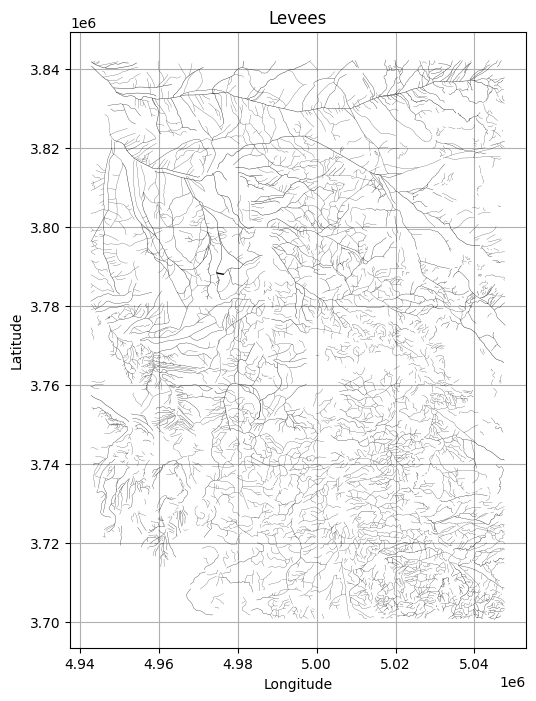

In [ ]:


# === Path to your shapefile ===
shp_path = f"{reference_data_path}/data/vector/UnderTheSands_Iraq_CFE_Network_of_levees_and_palaeo_channels.shp"

# === Load shapefile ===
gdf = gpd.read_file(shp_path)

# === Filter by Type == 2 ===
gdf = gdf[gdf["Type"] == 2]

if gdf.empty:
    raise ValueError("No features found with Type == 2.")

# === Define mapping from Size to linewidth ===
# You can adjust these if you want different visual scaling
size_to_width = {
    0.25: 0.15,
    0.5: 0.2,
    0.75: 0.25,
    1.0: 0.25
}

# Map 'Size' values to line widths (default to 1.0 if not in dict)
gdf["linewidth"] = gdf["Size"].map(size_to_width).fillna(1.0)

# === Plot ===
fig, ax = plt.subplots(figsize=(10, 8))
for lw, subset in gdf.groupby("linewidth"):
    subset.plot(ax=ax, linewidth=lw, edgecolor='black')

plt.title("Levees")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)
plt.show()


#### Clip the portion of the reference data

In [ ]:
import geopandas as gpd
import os
sector_name = "_".join(filename_to_detect.split("_")[:2])
print(sector_name)  # Output: CFE_c
sector = sector_name

# ================= USER INPUT =================
# Load the AOIs location
aoi_path = f"{git_path}/Dataset/AOI.geojson"              # EPSG:4326
reference_path = shp_path        # vector file
output_path = f"{reference_data_path}/AOI.gpkg"
aoi = gpd.read_file(aoi_path).to_crs(epsg=4326)
# Check what CRS was detected
aoi = gpd.read_file(aoi_path)
print(f"Detected CRS: {aoi.crs}")

def clip_to_sector(aoi_path, reference_path, output_path, sector_name):
    aoi = gpd.read_file(aoi_path)
    aoi_filtered = aoi[aoi["sector"] == sector_name].to_crs(epsg=4326)

    if len(aoi_filtered) == 0:
        raise ValueError(f"Sector '{sector_name}' not found. Available: {aoi['sector'].unique().tolist()}")

    ref = gpd.read_file(reference_path).to_crs(epsg=4326)
    clipped = gpd.clip(ref, aoi_filtered).to_crs(epsg=3857)

    # Drop or rename 'fid' column if it exists (conflicts with GPKG internal fid)
    if 'fid' in clipped.columns:
        clipped = clipped.rename(columns={'fid': 'orig_fid'})

    clipped.to_file(output_path, driver="GPKG")

    return clipped

# Usage
clipped = clip_to_sector(aoi_path, shp_path, output_path, sector)


CFE_c
Detected CRS: EPSG:4326


#### See the clipped data

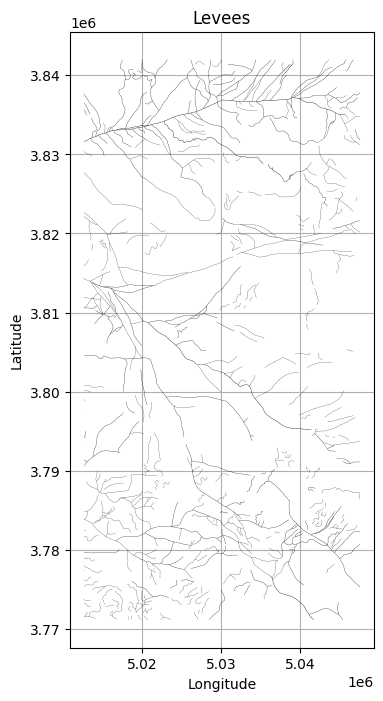

In [ ]:
# === Load shapefile ===
gdf = clipped

# === Filter by Type == 2 ===
gdf = gdf[gdf["Type"] == 2]
reference_file = gdf

if gdf.empty:
    raise ValueError("No features found with Type == 2.")

# === Define mapping from Size to linewidth ===
# You can adjust these if you want different visual scaling
size_to_width = {
    0.25: 0.15,
    0.5: 0.2,
    0.75: 0.25,
    1.0: 0.25
}

# Map 'Size' values to line widths (default to 1.0 if not in dict)
gdf["linewidth"] = gdf["Size"].map(size_to_width).fillna(1.0)

# === Plot ===
fig, ax = plt.subplots(figsize=(10, 8))
for lw, subset in gdf.groupby("linewidth"):
    subset.plot(ax=ax, linewidth=lw, edgecolor='black')

plt.title("Levees")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)
plt.show()


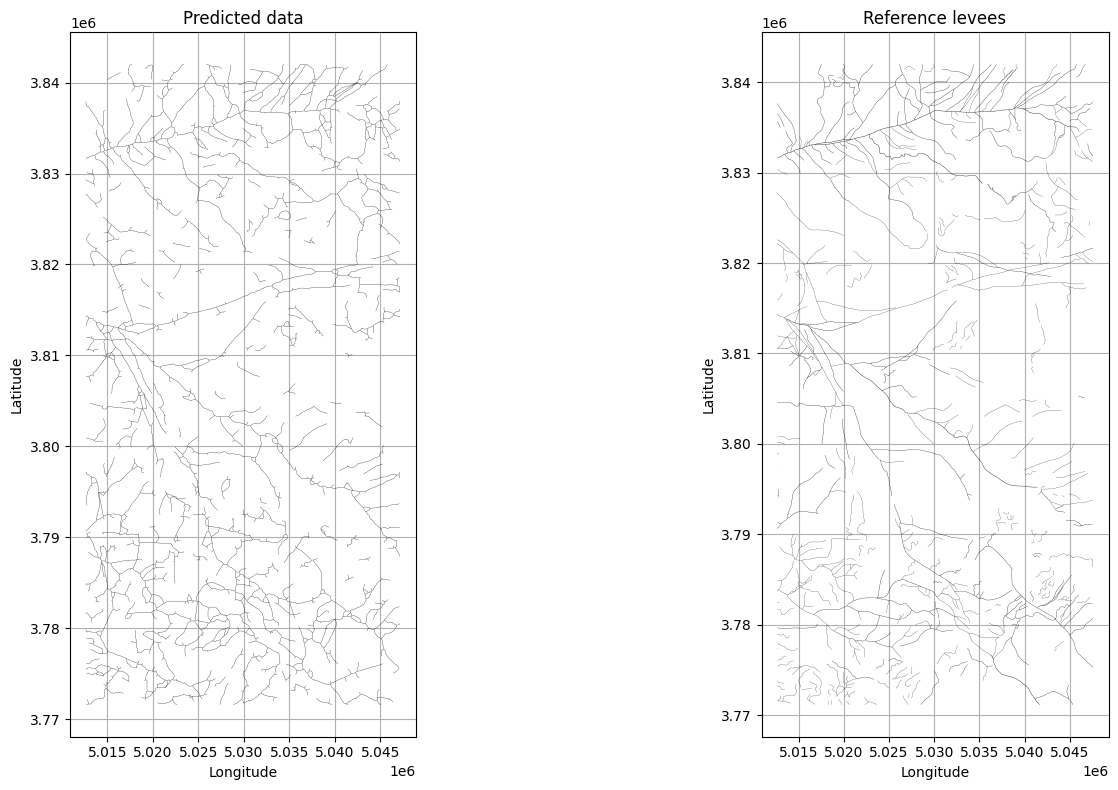

In [ ]:
# === Load shapefile ===
gdf = clipped

# === Filter by Type == 2 ===
gdf = gdf[gdf["Type"] == 2]

if gdf.empty:
    raise ValueError("No features found with Type == 2.")

# === Define mapping from Size to linewidth ===
size_to_width = {
    0.25: 0.15,
    0.5: 0.2,
    0.75: 0.25,
    1.0: 0.25
}

gdf["linewidth"] = gdf["Size"].map(size_to_width).fillna(1.0)

# === Create two subplots ===
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# === LEFT: edges_gdf ===
# === LEFT: edges_gdf ===
edges_gdf.plot(
    ax=ax1,
    edgecolor="black",
    linewidth=0.2   # thinner lines
)

ax1.set_title("Predicted data")
ax1.set_xlabel("Longitude")
ax1.set_ylabel("Latitude")
ax1.grid(True)

# === RIGHT: Levees (Type == 2) ===
for lw, subset in gdf.groupby("linewidth"):
    subset.plot(ax=ax2, linewidth=lw, edgecolor='black')

ax2.set_title("Reference levees")
ax2.set_xlabel("Longitude")
ax2.set_ylabel("Latitude")
ax2.grid(True)

plt.tight_layout()
plt.show()


--- Network Evaluation Metrics ---
Buffer distance: 25 units
Precision:  0.2420
Recall:     0.2231
F1 Score:   0.2321
IoU:        0.1313

Areas:
  TP: 2,874,883.03 sq units
  FP: 9,005,388.16 sq units
  FN: 10,013,439.27 sq units

--- Network Evaluation Metrics ---
Buffer distance: 50 units
Precision:  0.4173
Recall:     0.3856
F1 Score:   0.4008
IoU:        0.2506

Areas:
  TP: 9,902,389.81 sq units
  FP: 13,827,032.09 sq units
  FN: 15,781,403.81 sq units

--- Network Evaluation Metrics ---
Buffer distance: 75 units
Precision:  0.5269
Recall:     0.4882
F1 Score:   0.5069
IoU:        0.3395

Areas:
  TP: 18,729,591.06 sq units
  FP: 16,814,676.19 sq units
  FN: 19,631,147.37 sq units

--- Network Evaluation Metrics ---
Buffer distance: 100 units
Precision:  0.5938
Recall:     0.5525
F1 Score:   0.5724
IoU:        0.4009

Areas:
  TP: 28,099,104.11 sq units
  FP: 19,222,310.07 sq units
  FN: 22,761,725.75 sq units

--- Network Evaluation Metrics ---
Buffer distance: 125 units
Precisi

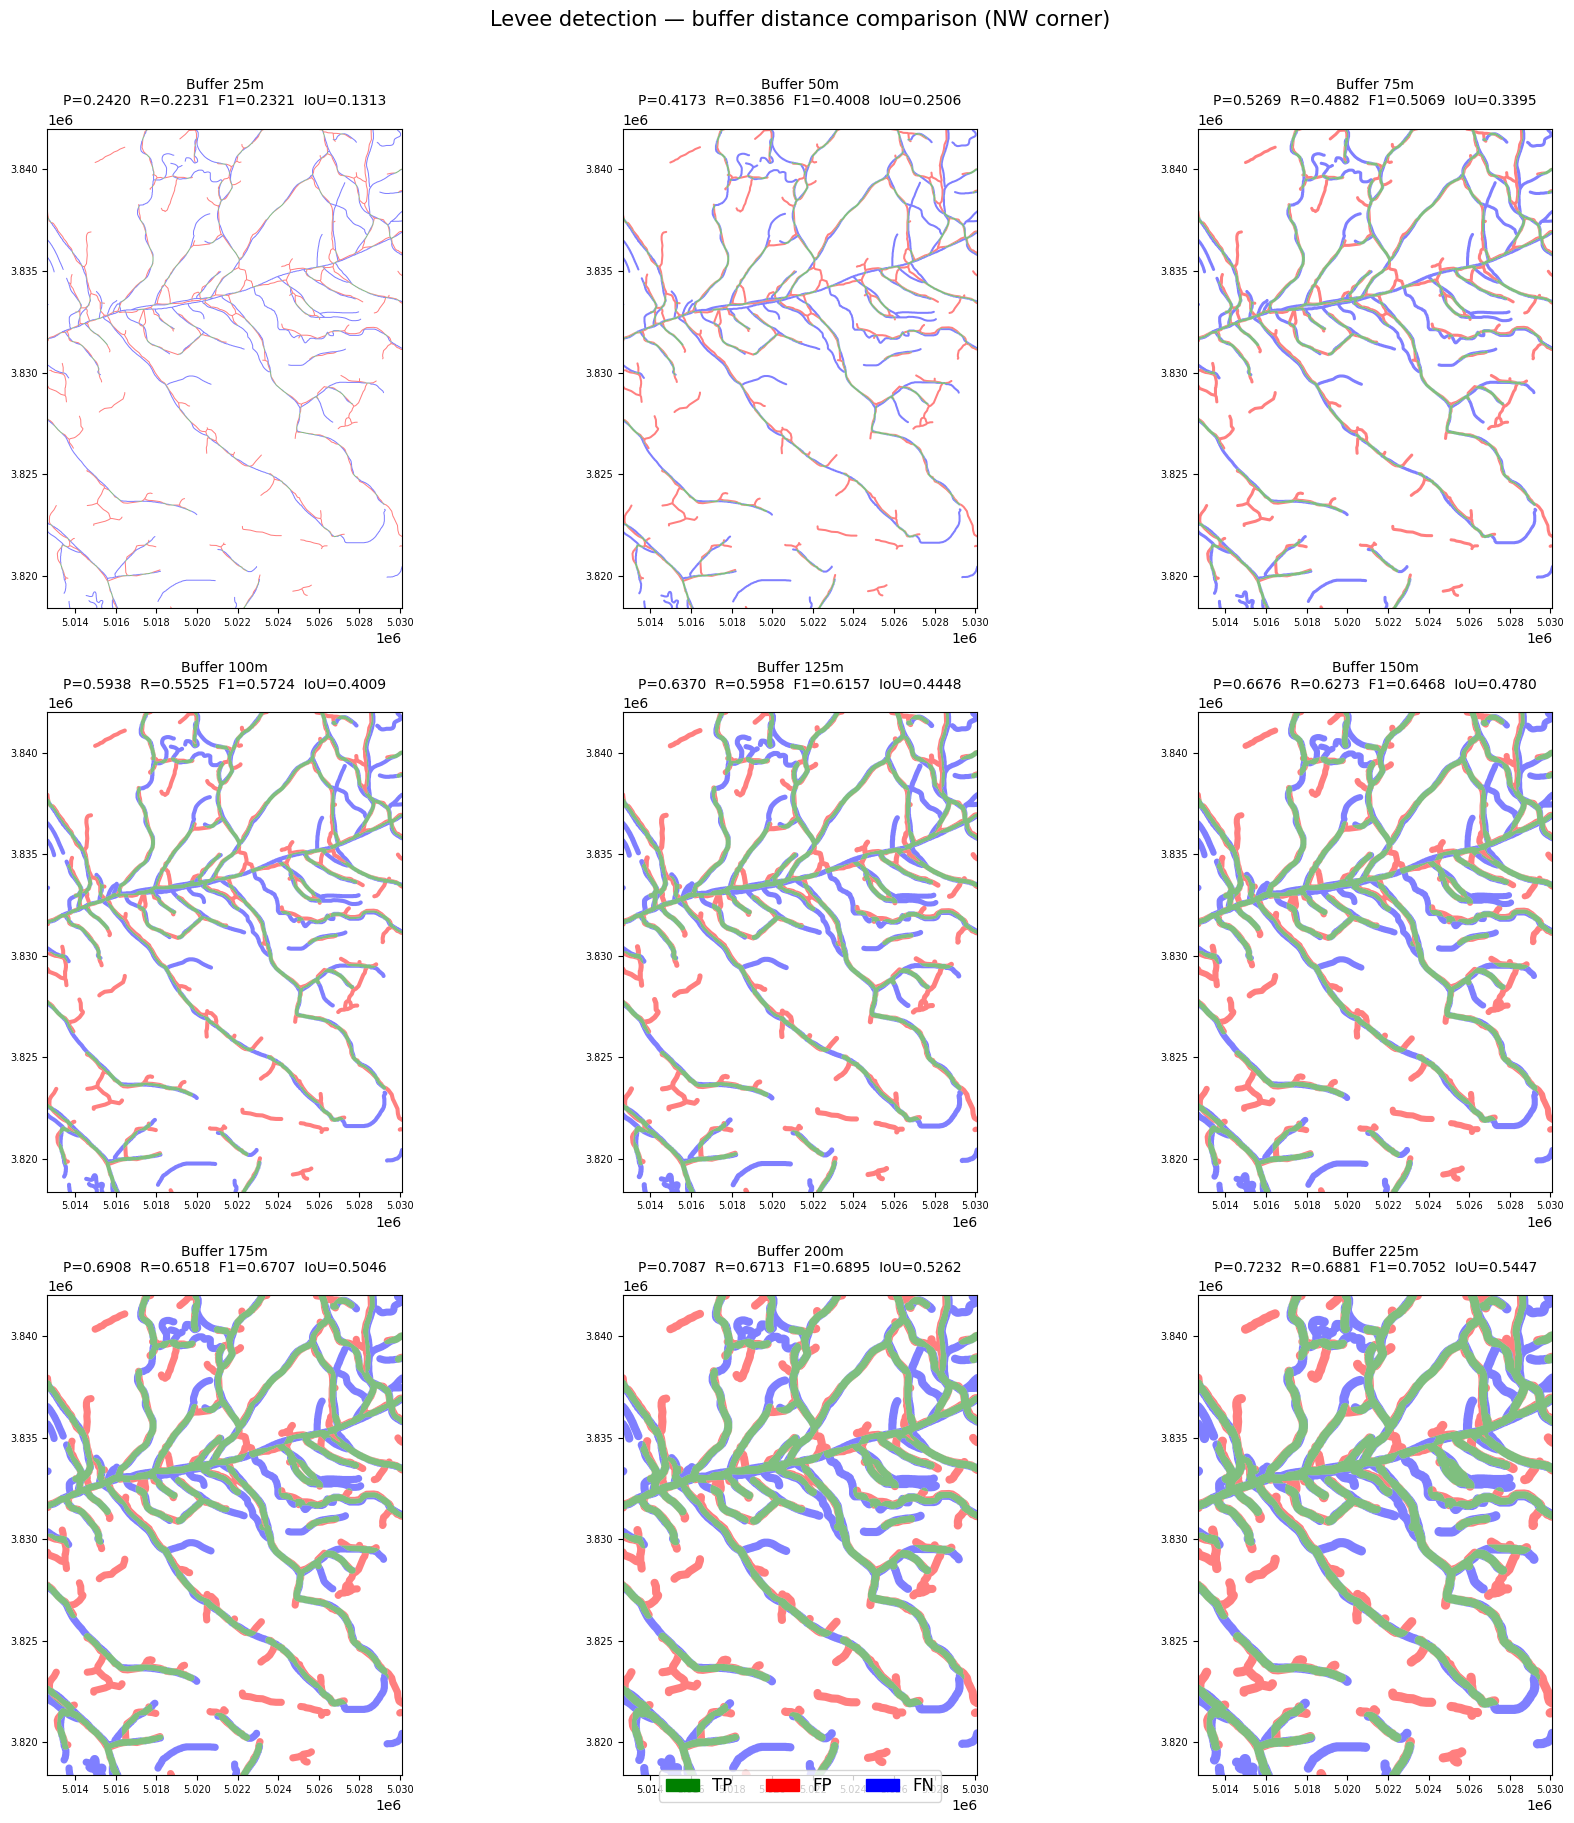

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import gc
import geopandas as gpd
from shapely.geometry import box
from Levees_DL.utils.metrics import compare_networks

buffer_distances = np.linspace(25, 225, 9, dtype=int)
color_map = {"TP": "green", "FP": "red", "FN": "blue"}

# ── Auto-calculate bounds from data ───────────────────────────────────────────
ref_full  = gpd.read_file(reference_file) if isinstance(reference_file, str) else reference_file.copy()
pred_full = edges_gdf.copy()

if ref_full.crs.to_epsg() != 3857:
    ref_full = ref_full.to_crs(3857)
if pred_full.crs.to_epsg() != 3857:
    pred_full = pred_full.to_crs(3857)

combined    = ref_full.total_bounds
pred_bounds = pred_full.total_bounds
xmin = min(combined[0], pred_bounds[0])
ymin = min(combined[1], pred_bounds[1])
xmax = max(combined[2], pred_bounds[2])
ymax = max(combined[3], pred_bounds[3])

total_width  = xmax - xmin
total_height = ymax - ymin

# NW corner: left ½ width, top ⅓ height
ZOOM_XMIN = xmin
ZOOM_XMAX = xmin + total_width / 2
ZOOM_YMIN = ymax - total_height / 3
ZOOM_YMAX = ymax

zoom_bbox = box(ZOOM_XMIN, ZOOM_YMIN, ZOOM_XMAX, ZOOM_YMAX)

# ── Clip inputs once ───────────────────────────────────────────────────────────
ref_clipped  = ref_full[ref_full.intersects(zoom_bbox)].copy()
pred_clipped = pred_full[pred_full.intersects(zoom_bbox)].copy()
ref_clipped["geometry"]  = ref_clipped.intersection(zoom_bbox)
pred_clipped["geometry"] = pred_clipped.intersection(zoom_bbox)
del ref_full, pred_full
gc.collect()

# ── Single combined figure: 3 cols × 3 rows ───────────────────────────────────
n_cols = 3
n_rows = int(np.ceil(len(buffer_distances) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 6 * n_rows))
axes = axes.flatten()

for idx, buffer_distance in enumerate(buffer_distances):
    ax = axes[idx]
    try:
        metrics = compare_networks(
            reference_path=ref_clipped,
            predicted_path=pred_clipped,
            buffer_distance=int(buffer_distance),
            crs=3857
        )
        gdf = metrics["comparison_gdf"]

        for label, color in color_map.items():
            subset = gdf[gdf["label"] == label]
            if not subset.empty:
                subset.plot(ax=ax, color=color, alpha=0.5)

        p, r, f1, iou = metrics["precision"], metrics["recall"], metrics["f1_score"], metrics["iou"]
        ax.set_title(f"Buffer {buffer_distance}m\nP={p:.4f}  R={r:.4f}  F1={f1:.4f}  IoU={iou:.4f}", fontsize=10)
        ax.set_xlim(ZOOM_XMIN, ZOOM_XMAX)
        ax.set_ylim(ZOOM_YMIN, ZOOM_YMAX)
        ax.set_aspect("equal")
        ax.tick_params(labelsize=7)

    except Exception as e:
        ax.set_title(f"Buffer {buffer_distance}m\nERROR: {e}", fontsize=9, color="red")

    finally:
        try:
            del metrics, gdf
        except NameError:
            pass
        gc.collect()

# ── Hide unused subplots ───────────────────────────────────────────────────────
for ax in axes[len(buffer_distances):]:
    ax.set_visible(False)

# ── Shared legend ──────────────────────────────────────────────────────────────
patches = [mpatches.Patch(color=c, label=l) for l, c in color_map.items()]
fig.legend(handles=patches, loc="lower center", ncol=3, fontsize=12, bbox_to_anchor=(0.5, 0.01))

fig.suptitle("Levee detection — buffer distance comparison (NW corner)", fontsize=15, y=1.01)
fig.tight_layout()
plt.show()

In [ ]:
import os
from Levees_DL.utils.metrics import compare_linear_vectors
import geopandas as gpd

metrics = compare_linear_vectors(
    reference_path=reference_file,
    predicted_path=edges_gdf,
    buffer_distance=225,
    crs=3857
)


print(f"Precision: {metrics['precision']:.4f}")
print(f"Recall: {metrics['recall']:.4f}")
print(f"F1 Score: {metrics['f1_score']:.4f}")
print(f"IoU: {metrics['iou']:.4f}")


--- Evaluation Metrics (Linear, buffer both) ---
Buffer distance: 225 units
Precision:  0.6583
Recall:     0.6859
F1 Score:   0.6718
IoU:        0.5058

Areas (sq units):
  TP: 436,714,157.69
  FP: 226,658,742.21
  FN: 200,012,145.19

Comparison saved to: linear_comparison_buf225.gpkg
Precision: 0.6583
Recall: 0.6859
F1 Score: 0.6718
IoU: 0.5058


In [ ]:
from Levees_DL.utils.metrics import compare_networks


metrics = compare_networks(
      reference_path=reference_file,
      predicted_path=edges_gdf,
      buffer_distance=125,   # 25 metres — adjust to your typical levee width
      crs=3857             # use a projected CRS matching your area (UTM zone etc.)
  )

print(f"{metrics['precision']:.4f}\t{metrics['recall']:.4f}\t{metrics['f1_score']:.4f}\t{metrics['iou']:.4f}")


--- Network Evaluation Metrics ---
Buffer distance: 125 units
Precision:  0.5690
Recall:     0.5948
F1 Score:   0.5816
IoU:        0.4101

Areas:
  TP: 215,381,408.22 sq units
  FP: 163,114,182.23 sq units
  FN: 146,753,399.18 sq units
0.5690	0.5948	0.5816	0.4101


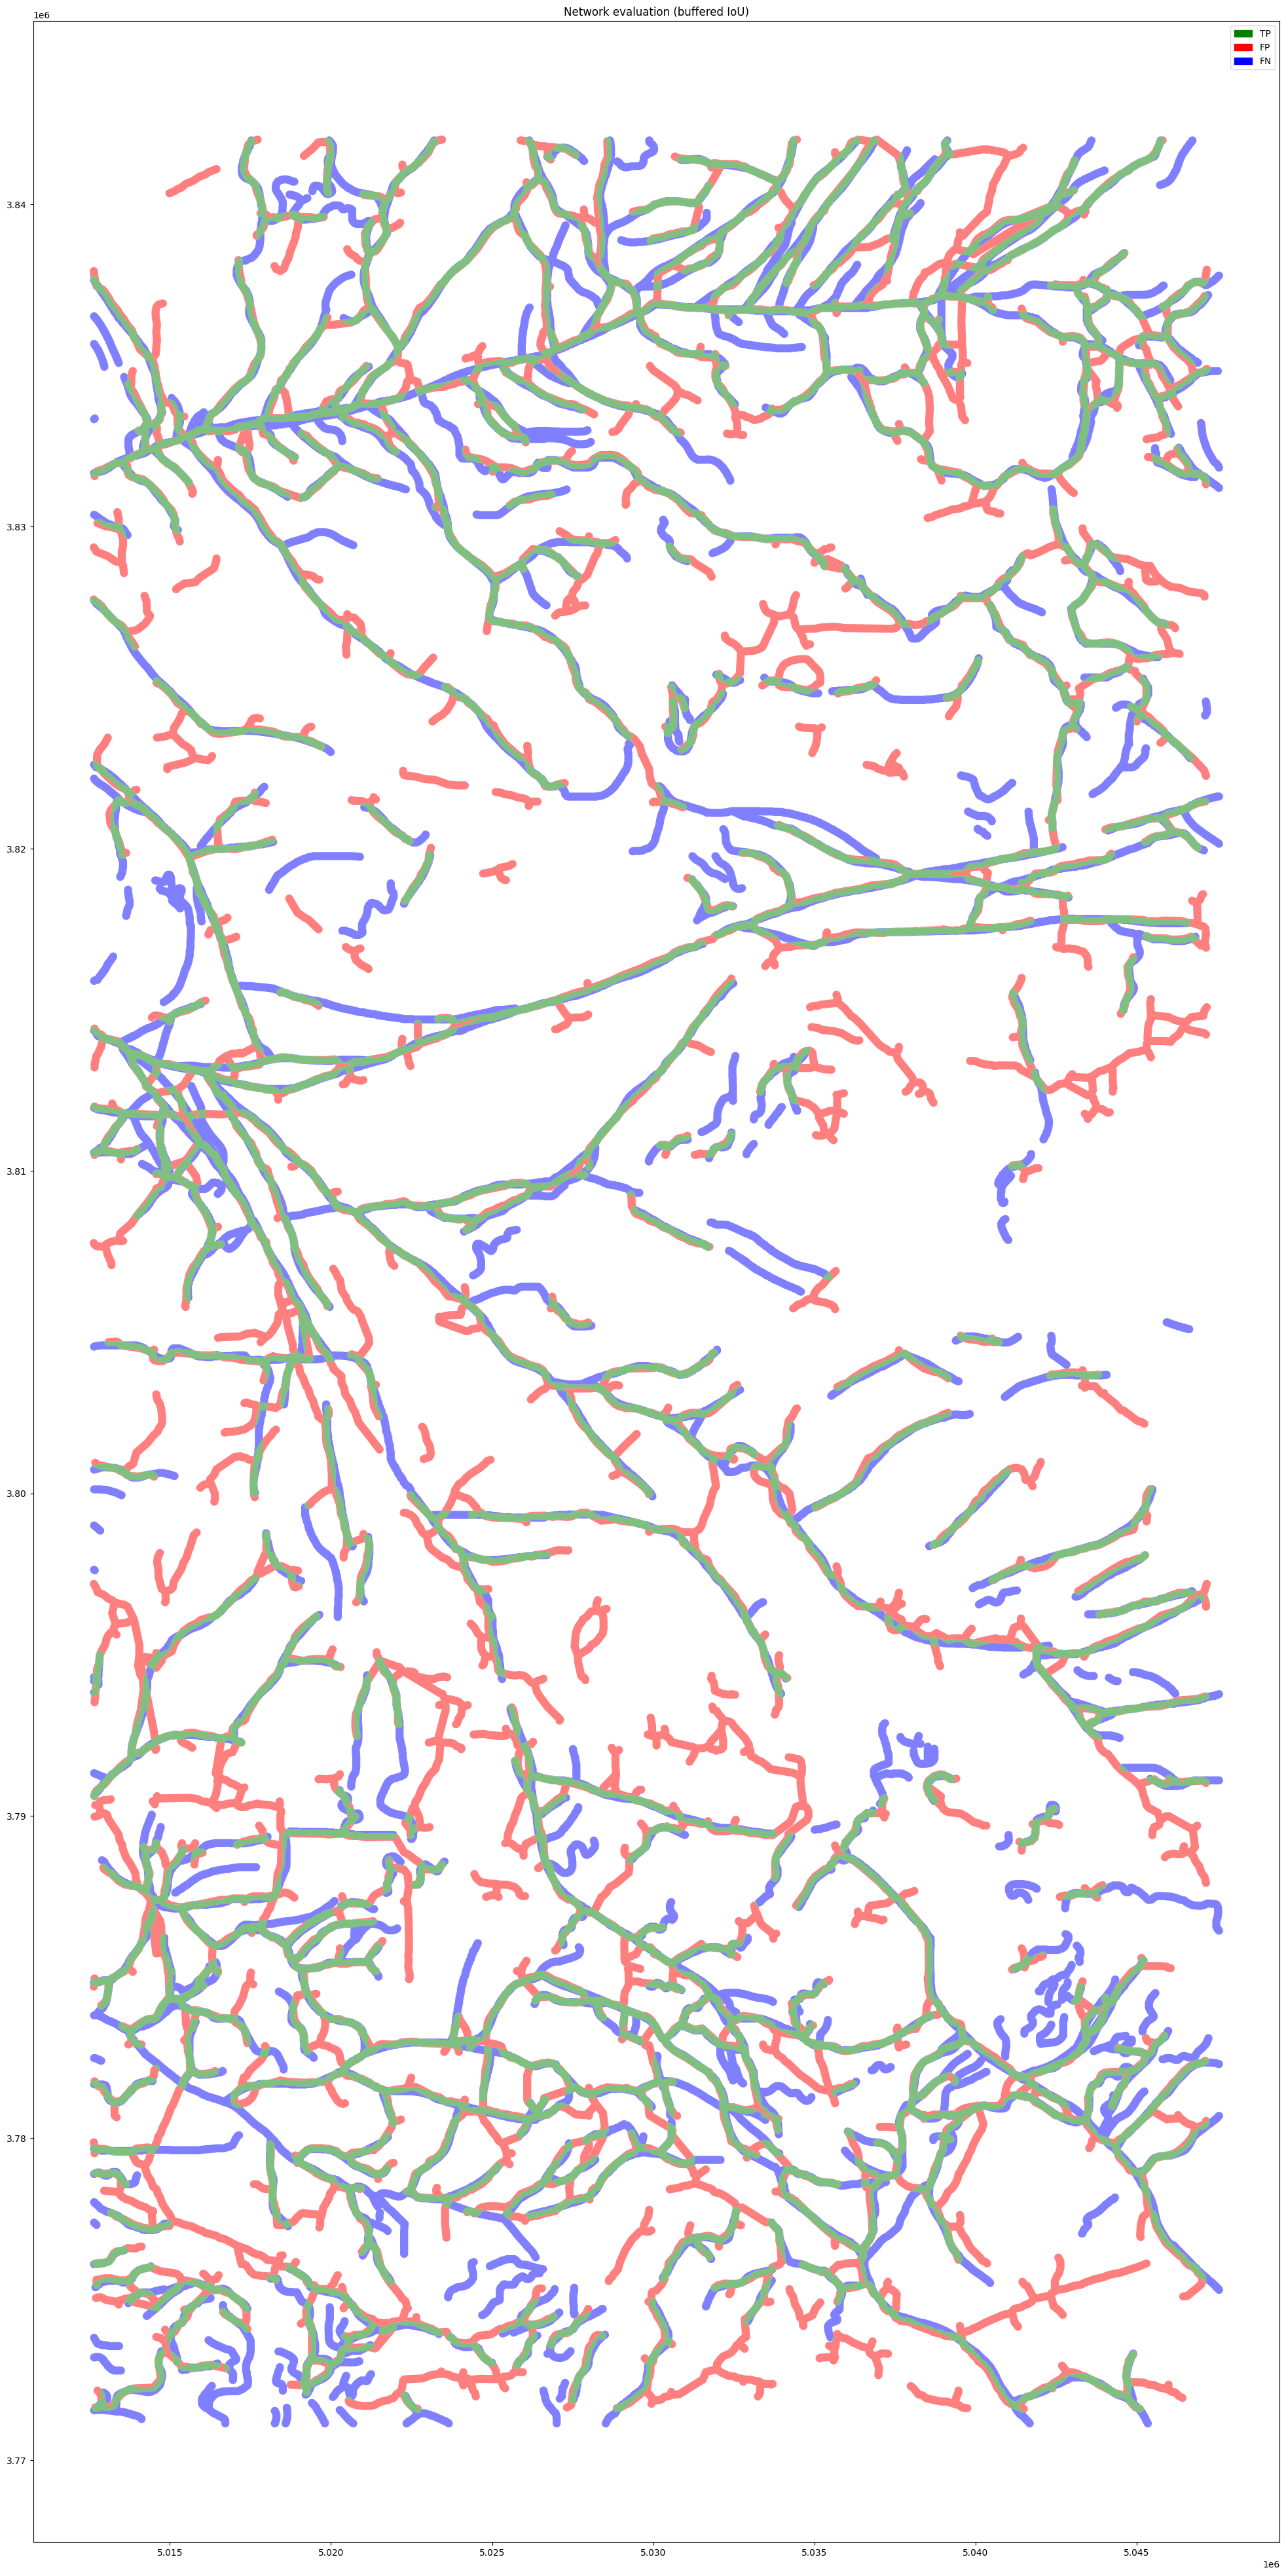

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

gdf = metrics["comparison_gdf"]

color_map = {"TP": "green", "FP": "red", "FN": "blue"}
fig, ax = plt.subplots(figsize=(50, 50))

for label, color in color_map.items():
    subset = gdf[gdf["label"] == label]
    if not subset.empty:
        subset.plot(ax=ax, color=color, alpha=0.5, label=label)

patches = [mpatches.Patch(color=c, label=l) for l, c in color_map.items()]
ax.legend(handles=patches)
ax.set_title("Network evaluation (buffered IoU)")
plt.show()

In [ ]:
from Levees_DL.utils.metrics import compare_line_segments
import geopandas as gpd

# Compare reference and predicted line segments
metrics = compare_line_segments(
    reference_path=reference_file,
    predicted_path=edges_gdf,
    segment_length=100,      # Segment lines into 100m pieces
    buffer_distance=175,   # 175m tolerance for matching
    output_path="comparison_output.gpkg",
    crs=3857                 # Use projected CRS (recommended)
)




print(f"Precision: {metrics['precision']:.4f}")
print(f"Recall: {metrics['recall']:.4f}")
print(f"F1 Score: {metrics['f1_score']:.4f}")
print(f"IoU: {metrics['iou']:.4f}")

Segmenting reference lines into 50m sections...
Reference: 621 lines → 29994 segments
Segmenting predicted lines into 50m sections...
Predicted: 2078 lines → 32177 segments

--- Line Comparison Summary (50m segments) ---
TP: 23110 segments, 1,122.36 km
FP: 9067 segments, 435.01 km
FN: 6895 segments, 339.31 km

--- Evaluation Metrics (Length-based) ---
Precision:  0.7207
Recall:     0.7679
F1 Score:   0.7435
IoU:        0.5918

Saved to: comparison_output.gpkg
Precision: 0.7207
Recall: 0.7679
F1 Score: 0.7435
IoU: 0.5918


6. Visualise the results



In [ ]:
#!pip install leaflet
!pip install leafmap
!pip install localtileserver

In [ ]:
import leafmap
from google.colab import output
output.enable_custom_widget_manager()

latitude = 31.52806
longitude = 65.24722

m = leafmap.Map(center=[latitude, longitude], zoom=14)

# Raster
raster_path = f"{basepath}/custom_comparison.tif"

palette = [
    "#e5350e",  # -1 FP
    "#0dff0d",  #  1 TP
    "#729bff",  #  2 FN
]

m.add_raster(
    raster_path,
    palette=palette,
    vmin=-1,
    vmax=2,
    nodata=0,
    layer_name="Raster Detection Results",
)

# Vector with style callback
vector_path = f"{basepath}/comparison_output.gpkg"

def style_function(feature):
    class_val = str(feature["properties"].get("class", ""))
    color_map = {
        "-1": "#e5350e",  # FP
        "1": "#0dff0d",   # TP
        "2": "#729bff",   # FN
    }
    color = color_map.get(class_val, "#808080")
    return {
        "color": color,
        "weight": 2,
        "fillColor": color,
        "fillOpacity": 0.3,
    }

m.add_vector(
    vector_path,
    style_callback=style_function,
    layer_name="Vector Detection Results",
)

# Legend
legend_dict = {
    "False Positives (FP)": "#e5350e",
    "True Positives (TP)": "#0dff0d",
    "False Negatives (FN)": "#729bff",
}

m.add_legend(title="Detection Results", legend_dict=legend_dict)
m.add_layer_control()
m